# Segmentação de letras - Parte 1
Começaremos pelas imagens que tem dimensões grandes mas que estão em condições adversas de luz: pouco contraste entre a letra e o fundo, imagem de captura ruim, fundo escuro...

## Abordagem: componentes conectados

Importando bibliotecas

In [1]:
import cv2 as cv
from skimage import measure
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path
import math
import os
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

Função `plot_all(str directory)`: exibe todas as imagens que estão no diretório-raiz `directory`.

In [2]:
def plot_all(directory):
    # Extensões de imagem válidas
    valid_extensions = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

    # Coleta todos os caminhos de imagens (recursivamente)
    image_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            if os.path.splitext(file)[1].lower() in valid_extensions:
                image_paths.append(os.path.join(root, file))

    # Aumente o número de colunas aqui
    n_cols = 5
    n_rows = -(-len(image_paths) // n_cols)  # arredonda pra cima

    # Ajuste do tamanho da figura
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2 * n_rows))
    axes = axes.flatten() if len(image_paths) > 1 else [axes]

    # Define tamanho máximo de exibição
    max_size = (600, 600)

    for ax, img_path in zip(axes, image_paths):
        try:
            # Abre imagem e corrige orientação EXIF automaticamente
            img = Image.open(img_path)
            img = ImageOps.exif_transpose(img)
            img = img.convert("RGB")

            # Redimensiona mantendo proporção
            img.thumbnail(max_size)

            # Exibe imagem
            ax.imshow(img)
            ax.set_title(os.path.basename(img_path), fontsize=8)
            ax.axis("off")
        except Exception as e:
            ax.set_title(f"Erro ao carregar:\n{os.path.basename(img_path)}", fontsize=8)
            ax.axis("off")

    # Remove subplots vazios
    for i in range(len(image_paths), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


## Etapa 1: Pré-processamento

Pasta raiz em `INPUT_ROOT_FOLDER`, pasta destino em `OUTPUT_ROOT_FOLDER`, com as transformações resultantes do pré-processamento.

In [9]:
INPUT_ROOT_FOLDER = 'bookpages'
OUTPUT_ROOT_FOLDER = 'bookpages/interim'

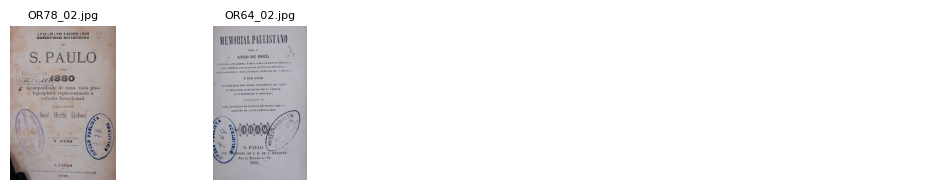

In [10]:
plot_all(f'{INPUT_ROOT_FOLDER}/raw')

### 1.1: Remoção de ruído e binarização
Para remoção de ruído, será aplicado filtro de mediana sobre as imagens, de kernel tamanho 15x15, para remoção de ruído 'sal e pimenta', seguido de binarização simples. Valores menores ou iguais a 127 são reduzidos a 0 (preto - idealmente, as letras), enquanto valores maiores que 127 são mudados a 255 (branco - idealmente, o fundo).

In [21]:
for current_path, subdirectories, files in os.walk(f'{INPUT_ROOT_FOLDER}/raw'):
        if not files: continue
        for filename in files:
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')): continue
            input_image_path = os.path.join(current_path, filename)
            image_base_name = os.path.splitext(filename)[0]
            output_image_dir = os.path.join(f'{OUTPUT_ROOT_FOLDER}/binarized')
            os.makedirs(output_image_dir, exist_ok=True)

            print(f"\nProcessing image: {input_image_path}")
            print(f"-> Image Code: '{image_base_name}'")
            print(f"-> Output will be saved to: {output_image_dir}")

            img = cv.imread(input_image_path, cv.IMREAD_GRAYSCALE)
            if img is None:
                print(f"  -> Error loading image. Skipping...")
                continue
            
            blur = cv.medianBlur(img, 15)
             
            _,binarized = cv.threshold(img,127,255,cv.THRESH_BINARY)

            cv.imwrite(f'{output_image_dir}/{image_base_name}.png', binarized)

            print("-> Saved at ", output_image_dir)


Processing image: bookpages/raw/OR78_02.jpg
-> Image Code: 'OR78_02'
-> Output will be saved to: bookpages/interim/binarized
-> Saved at  bookpages/interim/binarized

Processing image: bookpages/raw/OR64_02.jpg
-> Image Code: 'OR64_02'
-> Output will be saved to: bookpages/interim/binarized
-> Saved at  bookpages/interim/binarized


Exibindo os resultados da binarização + filtragem:

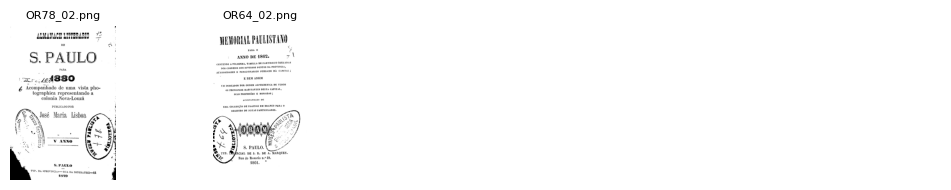

In [22]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/binarized')

### 1.2: Fechamento morfológico
O fechamento morfológico será aplicado para juntar componentes de letras que, por razões diversas (falhas de impressão, iluminação não uniforme, etc.) podem estar desconectadas após a binarização, o que afeta a segmentação que será feita em etapa futura. 

In [25]:
kernel = np.ones((7,7), np.uint8)

for current_path, subdirectories, files in os.walk(f'{OUTPUT_ROOT_FOLDER}/binarized'):
        if not files: continue
        for filename in files:
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')): continue
            input_image_path = os.path.join(current_path, filename)
            image_base_name = os.path.splitext(filename)[0]
            output_image_dir = os.path.join(f'{OUTPUT_ROOT_FOLDER}/morph_closed')
            os.makedirs(output_image_dir, exist_ok=True)

            print(f"\nProcessing image: {input_image_path}")
            print(f"-> Image Code: '{image_base_name}'")
            print(f"-> Output will be saved to: {output_image_dir}")

            img = cv.imread(input_image_path, cv.IMREAD_GRAYSCALE) 
            
            if img is not None:
                img_inverted = 255 - img
                closing_result = cv.morphologyEx(img_inverted, cv.MORPH_CLOSE, kernel)
                result = 255 - closing_result
                
                cv.imwrite(f'{output_image_dir}/{image_base_name}.png', result)

                print("Saved at ", output_image_dir)


Processing image: bookpages/interim/binarized/OR78_02.png
-> Image Code: 'OR78_02'
-> Output will be saved to: bookpages/interim/morph_closed
Saved at  bookpages/interim/morph_closed

Processing image: bookpages/interim/binarized/OR64_02.png
-> Image Code: 'OR64_02'
-> Output will be saved to: bookpages/interim/morph_closed
Saved at  bookpages/interim/morph_closed


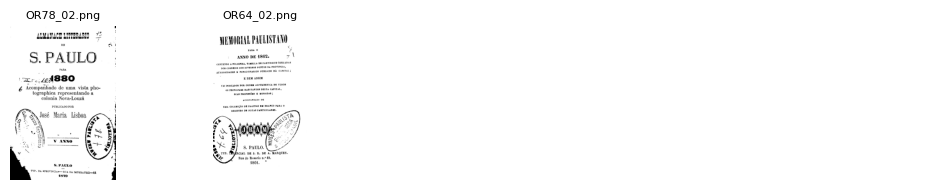

In [26]:
plot_all(f'{OUTPUT_ROOT_FOLDER}/morph_closed')

Apesar de, acima, haver destruição de detalhes das letras (veja `cod_045.png`, por exemplo), estamos interessados apenas nos **bounding boxes**, isto é, nos 'retângulos' que delimitam as letras. O pré-processamento está completo.

## Etapa 2: Segmentação utilizando componentes conexas
A segmentação é feita com base em componentes conexas. São consideradas componentes conexas pixels de valores distintos do fundo (de valor zero) que estão conectadas por vizinhança-8 (cima, baixo, esquerda, direita e diagonais). Cada componente é considerada, portanto, um caracter distinto.

Como dito anteriormente, estamos interessados apenas nos retângulos delimitadores das letras. Com os limites de cada letra em mãos, os recortes serão obtidos **das imagens originais** (localizados nas pastas `raw`).

Utilizamos, para tanto, o módulo `measure` da biblioteca `Scikit-image`. Esse módulo contém duas funções-chave: `measure.label`, que encontra as componentes conexas e estabelece rótulos para cada uma (0 para o fundo, e 1, 2, 3... para cada componente encontrada), e `measure.regionprops`, que extrai características quantitativas de cada objeto encontrado (inclusive delimitações da bounding box) e as guarda em um dicionário indexado pelo rótulo do objeto (ref.: [Documentação skimage.measure](https://scikit-image.org/docs/0.25.x/api/skimage.measure.html))

Trocamos as pastas de origem e destino nesta etapa. `AUX_ROOT_FOLDER` consiste na pasta com as imagens transformadas. `INPUT_ROOT_FOLDER` contém as imagens originais. `OUTPUT_ROOT_FOLDER` conterá os recortes, a partir das imagens originais, das componentes conexas encontradas nas imagens transformadas.

In [29]:
AUX_ROOT_FOLDER = 'bookpages/interim/morph_closed'
INPUT_ROOT_FOLDER = 'bookpages/raw'
OUTPUT_ROOT_FOLDER = 'bookpages/processed'

Abaixo, o código da segmentação. Veja que recortes cujo tamanho/número de pixels/área é menor que 100 não são salvos, como uma maneira de reduzir ruídos remanescentes.

In [30]:
for current_path, subdirectories, files in os.walk(INPUT_ROOT_FOLDER):
        if not files: continue
        for filename in files:

            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')): continue
            input_image_path = os.path.join(current_path, filename)
            image_base_name = os.path.splitext(filename)[0]
            output_image_dir = os.path.join(OUTPUT_ROOT_FOLDER, image_base_name)
            os.makedirs(output_image_dir, exist_ok=True)

            print(f"\nProcessing image: {input_image_path}")
            print(f"  -> Image Code: '{image_base_name}'")
            print(f"  -> Output will be saved to: {output_image_dir}")

            original_img = cv.imread(input_image_path, cv.IMREAD_GRAYSCALE)
            if original_img is None:
                print(f"  -> Error loading image. Skipping...")
                continue
            
            img = cv.imread(os.path.join(AUX_ROOT_FOLDER, f'{image_base_name}.png'))
            
            labeled_img, num_labels = measure.label(img, connectivity=2, background=255, return_num=True)
            props = measure.regionprops(labeled_img)

            for i in range(0, num_labels):
                bbox = props[i].bbox

                cropped_letter = original_img[bbox[0]:bbox[3], bbox[1]:bbox[4]]
                print(np.size(cropped_letter))

                if np.size(cropped_letter) < 100:
                    continue

                output_filename = f"{image_base_name}_{i:03d}.png"
                output_path = os.path.join(output_image_dir, output_filename)

                cv.imwrite(output_path, cropped_letter)
            


Processing image: bookpages/raw/OR78_02.jpg
  -> Image Code: 'OR78_02'
  -> Output will be saved to: bookpages/processed/OR78_02
1914
72
6
1
16
350
5481
1406
4
170
8568
5762
7315
4488
7236
7182
5535
6072
6072
8911
8379
8184
8448
4224
8122
9504
6812
6890
176
1728
2
2
1
12
2420
2
198
2464
77
33
2
4
4
1
24
144
6
2
1
972
4386
12
1517
1
1476
14
625
18
2
1
2
8
5
56
1
70
456
52460
47800
43365
54978
52514
47083
15554
825
4836
17385
2
3
3
60
380
468
6
15
3760
1
63
3
2
663
21
1554
26
14
30
444
9
9
300
2
169
4408
1116
4
169
128
9
1
19044
17820
19320
19320
638
540
2882
15857
3953
9164
56
2
154
30
1260
1
2
240
352
66
1
684
243
40
4
9
1
585
24
308
1071
2
2
144
152
2
6
48
14268
4293
5200
4320
196
5002
7189
7920
5510
4785
4029
2750
2520
4510
2475
2860
7410
8208
2784
1
22
528
1
1
2
9
16
7380
182
2508
4346
2496
1
2520
4160
2808
4080
2408
2173
2750
2365
2420
3978
2475
2090
2520
3472
6440
2332
2736
3024
1
1
108
2370
210
4860
5360
372
2
3
2420
2520
2530
5005
2754
2622
3078
2915
2688
9499
144
6
403
40
8
2
